<a id='k1'></a>

<a id='k3'></a>

<a id='k5'></a>

<a id='k7'></a>



# Kapitel 7 - Zufallszahlen - ein Energiemix

In den bisher betrachteten Beispielen systemwissenschaftlicher Modellbildung sind wir davon ausgegangen, dass wir die Daten, die wir dafür benötigen, kennen, dass wir also zum Beispiel wissen, wie groß die Wachstumsrate oder auch die Anfangsgröße einer Tierpopulation ist. Dies ist leider aber nicht immer der Fall. Oftmals haben wir bestenfalls eine mehr oder wenigerer gute Vorstellung über ein Intervall, innerhalb dessen sich die benötigten Daten bewegen. In diesen Fällen können wir <b>Zufallszahlen</b> heranziehen, um unser Modell an realistische Gegebenheiten anzunähern. Zum Glück stellt uns auch dafür Python die nötigen Werkzeuge zur Verfügung.

Um dies zu demonstrieren, wollen wir uns im Folgenden mit einem Energienetzwerk beschäftigen, bestehend aus Wind-, Wasser- und Kohlekraftwerken. Wir werden die Produktion dieser Kraftwerke dem Verbrauch gegenüberstellen und Strategien finden, wie man den Bedarf möglichst gut decken kann, und möglichst wenig fossile Brennstoffe verwenden zu müssen.

Wir beginnen unser diesbezügliches Modell ganz einfach mit einer For-Schleife, die Stunde für Stunde über den Simulationszeitraum iteriert. In dieses Grundgerüst bauen wir auch schon ein Wasserkraftwerk ein, das konstant Strom liefert. Um den produzierten Strom grafisch darzustellen, verwenden wir einen so genannten `Stack-Plot`:

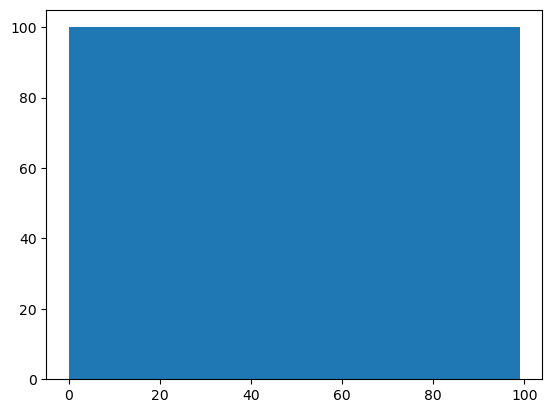

In [1]:
import matplotlib.pyplot as plt 

simulationszeit = 100
wasserkraft_liste = []

for zeit in range(simulationszeit):
    wasserkraft = 100
    wasserkraft_liste.append(wasserkraft)

plt.stackplot(range(simulationszeit), wasserkraft_liste)
plt.show()

Ein Wasserkraftwerk, das konstant die selbe Menge Strom liefert ist zwar parktisch, leider aber nicht realistisch. In der Realität wird es immer kleine Schwankungen geben, die wir auch in unsere Simulation einbauen sollten. Dazu benutzen wir <b>Zufallszahlen</b>. 

Für unser Wasserkraftwerk nehmen wir an, dass die Leistung meistens etwa 100 MW beträgt. Kleine Abweichungen werden häufiger sein, große Abweichungen seltener. Wir haben es also mit einer so genannten <b>Normal-</b> oder auch <b>Gauß-Verteilung</b> zu tun. Gauß-verteilte Zufallszahlen generiert man in Python mit dem Befehl `random.gauss(mittelwert, standardabweichung)` aus dem Packet `random`, das wir zunächst importieren müssen. Als Mittelwert verwenden wir 1 (mal 100 MW), als Standardabweichung können wir 0.1 benutzen (also 10%). Vereinfacht gesagt heißt das, dass die Zahlen, die damit generiert werden, im Durchschnitt 10% vom Mittelwert entfernt liegen, und zwar, je größer die Abweichung ist, umso seltener.

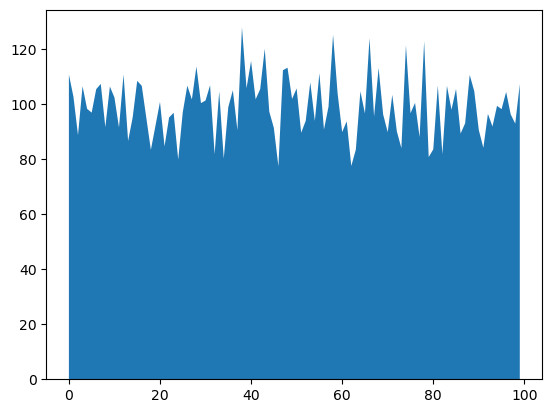

In [2]:
import matplotlib.pyplot as plt 
import random


simulationszeit = 100
wasserkraft_liste = []

for zeit in range(simulationszeit):
    wasserkraft = 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)

plt.stackplot(range(simulationszeit), wasserkraft_liste)
plt.show()

Neben einem Wasserkraftwerk möchten wir nun auch ein Windkraftwerk in unser Stromnetz einbauen. Die Leistung von Windkraftwerken ist stärker vom Zufall abhängig: bei Windstille produzieren sie gar nichts, aber auch zu starker Wind macht ihnen Probleme. Ein Gauß-Verteilung ist hier also nicht sinnvoll, wenn wir abbilden wollen, dass ein Windkraftwerk hin und wieder auch keinen Strom liefert. 

Wir können dazu aber <b>gleich-verteilte</b> Zufallszahlen heranziehen. Bei gleichverteilten Zufallszahlen ist jede Zahl gleich wahrscheinlich. Der folgende Plot illustriert den Unterschied zwischen Gauß-verteilten und gleich-verteilten Zufallszahlen. Wir verwenden den Befehl `random.uniform(0, 20)`, um reelle Zahlen zwischen 0 und (ausschließlich) 20 zu erzeugen. Diese werden zu 90 hinzu addiert, um eine ebenfalls um 100 variierende Verteilung zu erzeugen. Zum Plotten verwenden wir hier den Befehl `hist`, der ein Histogramm der erzeugten Daten zeichnet.

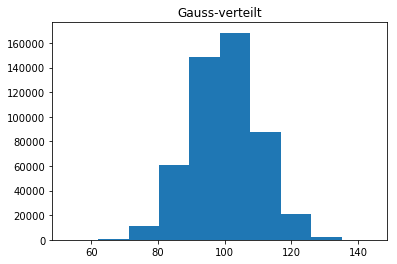

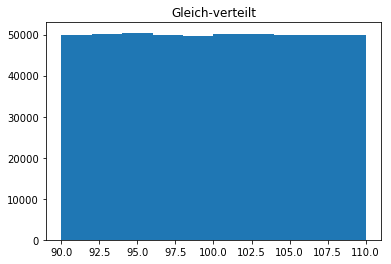

In [21]:
gauss=[]
gleich=[]

for it in range(500000):
    gauss.append(random.gauss(100, 10))
    gleich.append(90 + random.uniform(0, 20))

plt.hist(gauss)
plt.title('Gauss-verteilt')

plt.figure()
plt.hist(gleich);
plt.title('Gleich-verteilt')    
plt.show()

Unser Windkraftwerk soll eine maximale Leistung von 7 MW besitzen. Bei Windstille kann es aber vorkommen, dass auch gar kein Strom geliefert wird. Wir verwenden für die Leistung des Windkraftwerks also eine Zufallszahl zwischen 0 und 7, die wir mit dem Befehl `random.uniform()` erzeugen. Pythons <b>Stackplot</b> liefert uns die bequeme Möglichkeit, die zusätzlich zu den 100% Wasserkraft erzeugte Windenergie einfach grafisch auf die Wasserkraft auf zu addieren. Zur Unterscheidung der beiden Energiearten verwenden wir zwei unterschiedliche Blautöne: `darkblue` und `skyblue`.  

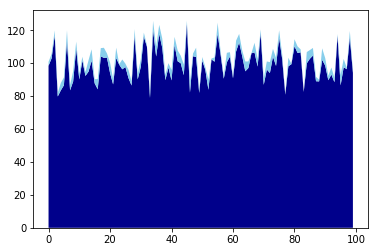

In [8]:
import matplotlib.pyplot as plt 
import random


simulationszeit = 100
wasserkraft_liste = []
windkraft_liste = []

for zeit in range(simulationszeit):
    wasserkraft = 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)
    windkraft = random.uniform(0, 7)
    windkraft_liste.append(windkraft)

plt.stackplot(range(simulationszeit), wasserkraft_liste, windkraft_liste, colors = ('darkblue', 'skyblue'))
plt.show()

Wir sehen, dass der Beitrag eines einzelnen Windkraftwerks, im Vergleich zu einem Wasserkraftwerk, nur eher wenig ausmacht. Wir sollten unser Modell also ausbauen, sodass wir die Zahl der jeweiligen Kraftwerke bestimmen können. Das wird es uns später erlauben zu bestimmen, wie viele Kraftwerke wir von welchem Typ benötigen.

Wir gehen hier im Folgenden zunächst von 10 Windkraftwerken und einem Wasserkarftwerk aus.

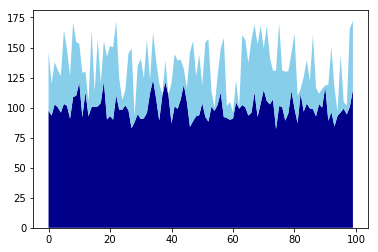

In [9]:
import matplotlib.pyplot as plt 
import random

simulationszeit = 100
windkraft_anzahl = 10
wasserkraft_anzahl = 1

wasserkraft_liste = []
windkraft_liste = []

for zeit in range(simulationszeit):
    wasserkraft = wasserkraft_anzahl * 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)
    windkraft = windkraft_anzahl * random.uniform(0, 7)
    windkraft_liste.append(windkraft)

plt.stackplot(range(simulationszeit), wasserkraft_liste, windkraft_liste, colors=('darkblue', 'skyblue'))
plt.show()

Sollten wir nun als Vorgabe haben, dass zu jeder Zeit mindestens 150 MW Strom verfügbar sein sollen, so sehen wir, dass die Anzahl unserer Windkraftwerke noch nicht ausreicht:

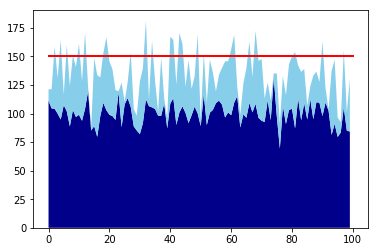

In [10]:
import matplotlib.pyplot as plt 
import random


simulationszeit = 100
windkraft_anzahl = 10
wasserkraft_anzahl = 1

wasserkraft_liste = []
windkraft_liste = []

for zeit in range(simulationszeit):
    wasserkraft = wasserkraft_anzahl * 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)
    windkraft = windkraft_anzahl * random.uniform(0, 7)
    windkraft_liste.append(windkraft)

plt.stackplot(range(simulationszeit), wasserkraft_liste, windkraft_liste, colors = ('darkblue', 'skyblue'))
# zeichne eine rote Linie in der Höhe von 150
plt.plot((0, 100),(150, 150), c = "red", lw = 2)
plt.show()

Wir müssen die Anzahl an Windkraftwerken also noch ein wenig erhöhen:

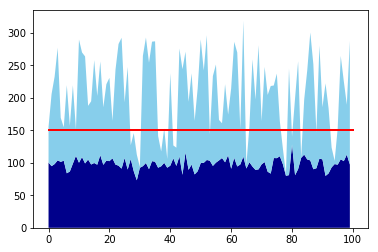

In [11]:
import matplotlib.pyplot as plt 
import random


simulationszeit = 100
windkraft_anzahl = 30
wasserkraft_anzahl = 1



wasserkraft_liste = []
windkraft_liste = []

for zeit in range(simulationszeit):
    wasserkraft = wasserkraft_anzahl * 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)
    windkraft = windkraft_anzahl * random.uniform(0, 7)
    windkraft_liste.append(windkraft)

plt.stackplot(range(simulationszeit), wasserkraft_liste, windkraft_liste, colors = ('darkblue', 'skyblue'))
plt.plot((0, 100), (150, 150), c = "red", lw = 2)
plt.show()

Wir sehen, dass, auch wenn wir 30 Windkraftwerke vorsehen und wir damit zu manchen Zeiten doppelt so viel Strom produzieren wie benötigt, es immer noch Zeiten gibt, zu denen wir die 150 MW Marke nicht erreichen. Wo liegt das Problem?

Das Problem liegt in der Eigenart der Windenergie. Bei Windstille produziert keines der 30 Windkraftwerke Strom. Wir haben beim Erstellen unseres Modells implizit angenommen, dass alle Windkraftwerke in der selben Region liegen und damit von den selben Windverhältnissen betroffen sind. In unserem Programmcode verwenden alle Kraftwerke die gleiche Zufallszahl: Wenn also in einer Stunde "Windstille" gewürfelt wird, dann gilt das für alle Kraftwerke. 

Wir könnten aber auch annehmen, dass die Krafwerke so weit voneinander entfernt stehen, dass es für jedes Kraftwerk andere Windverhältnisse gibt. Aber ändert das etwas? Wird dann im Mittel nicht genau gleich viel Strom produziert? 

Probieren wir es aus: Ändern wir unser Programm, sodass für jedes Kraftwerk eine eigene Zufallszahl vorgibt, wieviel Strom gerade produziert wird.

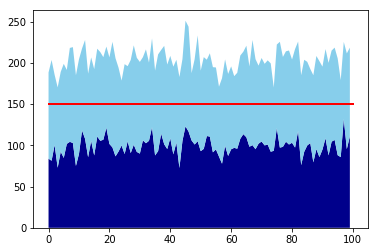

In [12]:
import matplotlib.pyplot as plt 
import random


simulationszeit = 100
windkraft_anzahl = 30
wasserkraft_anzahl = 1

wasserkraft_liste = []
windkraft_liste = []

for zeit in range(simulationszeit):
    wasserkraft = wasserkraft_anzahl * 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)
    windkraft = 0
    for kraftwerke in range(windkraft_anzahl):
        windkraft = windkraft + random.uniform(0, 7)
    windkraft_liste.append(windkraft)

plt.stackplot(range(simulationszeit), wasserkraft_liste, windkraft_liste, colors = ('darkblue', 'skyblue'))
plt.plot((0, 100), (150, 150), c = "red", lw = 2)
plt.show()

Wir sehen: obwohl im Mittel gleich viel Strom produziert wird, macht die Annahme, dass die Windkraftwerke von unterschiedlichen Windverhältnissen betroffen sind, einen großen Unterschied: wenn wir für jedes Kraftwerk eine eigene Zufallszahl erzeugen, mittelt sich das Ergebnis besser. Es gibt weniger Spitzen und weniger Senken, die Stromproduktion ist näher am Mittelwert.

Das ist eine grundlegende Eigenschaft von Zufallszahlen: Wenn man sehr viele davon verwendet, ist das Ergebnis immer sehr nahe am Mittelwert der möglichen Resultate.

Mit dem nun vorliegenden Modell schaut es also so aus, als würden wir sicherstellen können, dass immer 150 MW Strom verfügbar sind. Was passiert aber, wenn wir miteinbeziehen, dass Windkraftwerke einmal defekt werden können? Wie bauen wir so ein Zufallsereignis in unsere Simulation ein?

### Zufallsereignisse mit Python 

Wir haben bisher gelernt, wie man zufällige Zahlen erstellt. Was aber, wenn wir keine Zahl erzeugen wollen, sondern ein Ereignis - z.B. einen Defekt in einem Windkraftwerk -, das mit bestimmter Wahrscheinlichkeit auftritt? Wir können dazu Zufallszahlen mit `If-Abfragen` kombinieren.

Dazu benutzen wir den Umstand, dass 10% der Zahlen von 1 bis 100 kleiner oder gleich 10 sind. Und 50% der Zahlen sind kleinergleich 50. Im Code könnten wir also schreiben:

In [27]:
chance = 50
zufallszahl = random.uniform(0, 100)
if zufallszahl <= chance:
    print("KOPF!")
else:
    print("ZAHL!")

KOPF!


Das heißt, wir vergleichen hier die prozentuelle Chance eines Zufallsereignisses mit einer Zufallszahl und können somit sicher sein, dass dieses Ereignis auch mit genau dieser Chance passiert.

Bauen wir so eine Chance in unsere Simulation ein. Wir nehmen an, dass jede Stunde eine 10%-Chance besteht, dass ein Defekt im Windkraftwerk für einen Ausfall der Stromversorgung sorgt:

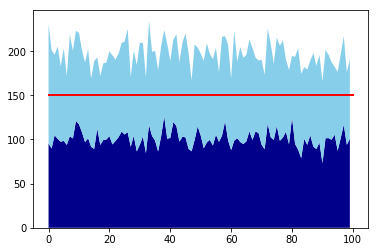

In [13]:
import matplotlib.pyplot as plt 
import random


simulationszeit = 100
windkraft_anzahl = 30
wasserkraft_anzahl = 1

wasserkraft_liste = []
windkraft_liste = []

for zeit in range(simulationszeit):
    wasserkraft = wasserkraft_anzahl * 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)
    windkraft = 0
    for kraftwerke in range(windkraft_anzahl):
        if random.uniform(0, 100) <= 10:
            # STÖRUNG: kein Strom wird produziert
            windkraft = windkraft + 0
        else:
            # Normalbetrieb: 
            windkraft = windkraft + random.uniform(0, 7)
    windkraft_liste.append(windkraft)

plt.stackplot(range(simulationszeit), wasserkraft_liste, windkraft_liste, colors = ('darkblue', 'skyblue'))
plt.plot((0, 100), (150, 150), c = "red", lw = 2)
plt.show()

Wir sehen, dass wir, obwohl es manchmal schon knapp wird, die Stromversorgung meistens noch sicherstellen können. Erhöhen wir aber die Ausfallchance zum Beispiel auf 50%, so sieht die Sache anders aus.

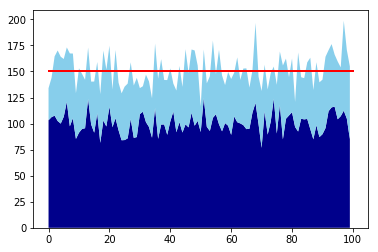

In [14]:
import matplotlib.pyplot as plt 
import random


simulationszeit = 100
windkraft_anzahl = 30
wasserkraft_anzahl = 1

wasserkraft_liste = []
windkraft_liste = []

for zeit in range(simulationszeit):
    wasserkraft = wasserkraft_anzahl * 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)
    windkraft = 0
    for kraftwerke in range(windkraft_anzahl):
        if random.uniform(0, 100) <= 50:
            # STÖRUNG: kein Strom wird produziert
            windkraft = windkraft + 0
        else:
            # Normalbetrieb: 
            windkraft = windkraft + random.uniform(0, 7)
    windkraft_liste.append(windkraft)

plt.stackplot(range(simulationszeit), wasserkraft_liste, windkraft_liste, colors = ('darkblue', 'skyblue'))
plt.plot((0, 100), (150, 150), c = "red", lw = 2)
plt.show()

Um noch etwas mehr über Zufallsgeneratoren zu lernen, wollen wir im Folgenden noch ein weiteres Kraftwerk in unser Stromnetz einbauen. Wir nehmen dazu ein eher unzuverlässiges Kohlekraftwerk an, das nur drei Betriebsmodi hat: "Stillstand" (0 MW), "Normalbetrieb" (20 MW) und "Hochbetrieb" (70 MW). In unserem Beispiel treten diese drei Betriebsmodi zufällig auf, kein anderer MW-Wert kann produziert werden. 

Wie würden wir das am besten umsetzen? Eine Zufallszahl zwischen 0 und 70 wäre schon einmal falsch, 3 aufeinanderfolgende 33%-Chancen wären auch nicht richtig, da in dem Fall ja mehrere Betriebsmodi auf einmal möglich wären. In Pyhton gibt es glücklichweise eine ganz einfache Lösung für solche Probleme: der Befehl `random.choice((a, b, c))` trifft eine zufällige Entscheidung zwischen a, b und c, wobei a, b und c nicht einmal Zahlen sein müssen. Bauen wir damit das Kraftwerk in unsere Simulation ein.

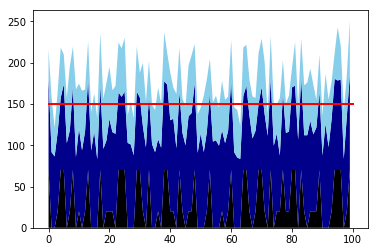

In [18]:
import matplotlib.pyplot as plt 
import random


simulationszeit = 100
windkraft_anzahl = 30
wasserkraft_anzahl = 1



wasserkraft_liste = []
windkraft_liste = []
kohlekraft_liste = []

for zeit in range(simulationszeit):
    wasserkraft = wasserkraft_anzahl * 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)
    windkraft = 0
    for kraftwerke in range(windkraft_anzahl):
        if random.uniform(0, 100) <= 50:
            # STÖRUNG: kein Strom wird produziert
            windkraft = windkraft + 0
        else:
            # Normalbetrieb: 
            windkraft = windkraft + random.uniform(0, 7)
    windkraft_liste.append(windkraft)
    
    kohlekraft = random.choice((0, 20, 70))
    kohlekraft_liste.append(kohlekraft)

plt.stackplot(range(simulationszeit), kohlekraft_liste, wasserkraft_liste, windkraft_liste, 
              colors = ('black', 'darkblue','skyblue'))
plt.plot((0, 100), (150, 150), c = "red", lw = 2)
plt.show()

Freilich gibt es noch Probleme, die wir mit unserer bisherigen Kenntnis von Zufallszahlen noch nicht darstellen können: Nehmen wir etwa an, es gäbe innerhalb des Simulationszeitraumes eine Stunde, in der das Stromnetz eine besondere Last erfährt. Der Verbrauch steigt hierbei auf 200 MW. Wir wissen jedoch nicht, wann genau diese Stunde sein wird, wir wissen nur dass es eine solche Stunde gibt. 

Wäre diese Stunde ganz am Anfang der Simulationszeit, wäre es ein einfaches Problem:

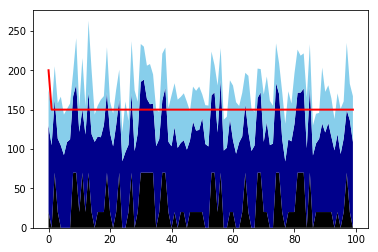

In [17]:
import matplotlib.pyplot as plt 
import random


simulationszeit = 100
windkraft_anzahl = 30
wasserkraft_anzahl = 1



wasserkraft_liste = []
windkraft_liste = []
kohlekraft_liste = []
verbrauch_liste = []

for zeit in range(simulationszeit):
    verbrauch_liste.append(150)
    wasserkraft = wasserkraft_anzahl * 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)
    windkraft = 0
    for kraftwerke in range(windkraft_anzahl):
        if random.uniform(0, 100) <= 50:
            # STÖRUNG: kein Strom wird produziert
            windkraft = windkraft + 0
        else:
            #Normalbetrieb: 
            windkraft = windkraft + random.uniform(0, 7)
    windkraft_liste.append(windkraft)
    
    kohlekraft= random.choice((0, 20, 70))
    kohlekraft_liste.append(kohlekraft)

plt.stackplot(range(simulationszeit), kohlekraft_liste, wasserkraft_liste, windkraft_liste,
              colors = ('black', 'darkblue', 'skyblue'))

#erstes element von verbrauch_liste auf 200 setzen:
verbrauch_liste[0] = 200

plt.plot(verbrauch_liste, c= "red", lw = 2)
plt.show()

Was aber, wenn diese überhöhte Energienachfrage einfach irgendwann auftritt? In diesem Fall hilft uns der Python-Befehl `random.shuffle(liste)`. Dieser mischt die Einträge einer Liste durcheinander. Damit kann man nicht nur Karten mischen...

In [32]:
karten = ['Herz 2', 'Herz 3', 'Herz 4','Herz 5','Herz 6','Herz 7']
random.shuffle(karten)
print(karten)

['Herz 3', 'Herz 6', 'Herz 7', 'Herz 2', 'Herz 5', 'Herz 4']


... sondern auch unser oben genanntes Problem lösen:

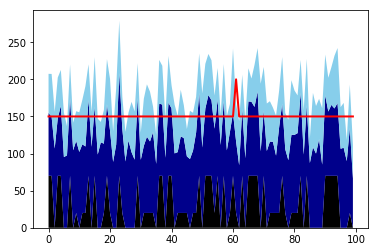

In [19]:
import matplotlib.pyplot as plt 
import random


simulationszeit = 100
windkraft_anzahl = 30
wasserkraft_anzahl = 1

wasserkraft_liste = []
windkraft_liste = []
kohlekraft_liste = []
verbrauch_liste = []

for zeit in range(simulationszeit):
    verbrauch_liste.append(150)
    wasserkraft = wasserkraft_anzahl * 100 * random.gauss(1, 0.1)
    wasserkraft_liste.append(wasserkraft)
    windkraft = 0
    for kraftwerke in range(windkraft_anzahl):
        if random.uniform(0, 100) <= 50:
            # STÖRUNG: kein Strom wird produziert
            windkraft = windkraft + 0
        else:
            # Normalbetrieb: 
            windkraft = windkraft + random.uniform(0, 7)
    windkraft_liste.append(windkraft)
    
    kohlekraft= random.choice((0, 20, 70))
    kohlekraft_liste.append(kohlekraft)

plt.stackplot(range(simulationszeit), kohlekraft_liste, wasserkraft_liste, windkraft_liste,
              colors=('black','darkblue','skyblue'))

# erstes Element der verbrauch_liste auf 200 setzen:
verbrauch_liste[0]=200
# shuffeln der gesamten Liste
random.shuffle(verbrauch_liste)

plt.plot(verbrauch_liste, c = "red", lw = 2)
plt.show()

## Zusammenfassung

### Zufallszahlen

Zufallszahlen werden in Python mit dem Paket `random` generiert. Es gibt verschiedene Befehle, die unterschiedliche Verteilungen von Zufallszahlen erzeugen.

**Gleich-verteilte (reelle) Zufallszahlen** erstellt man mit `random.uniform(a, b)`, wobei `a` die kleinste mögliche Zahl ist und `b` die obere Grenze markiert, bis zu der (aber ausschließlich der) Zufallszahlen erzeugt werden. Alle Zahlen von `a` bis (exklusive) `b` treten gleich wahrscheinlich auf. Somit lassen sich auch prozentuelle Wahrscheinlichkeiten leicht implementieren: Da 10% aller Zahlen zwischen 0 und 100 kleiner als 10 sind, und in gleichverteilten Zufallszahlen alle Zahlen gleich wahrscheinlich sind, wird die if-Abfrage `if random.uniform(0, 100) < 10` in etwa 10 Prozent der Fälle `true` liefern.

**Normal-verteilte Zufallszahlen** erstellt man mit `random.gauss(m, s)`, wobei `m` den Mittelwert der erzeugten Verteilung angibt und `s` die Standardabweichung. Der genaue Wertebereich ist also schwer abzuschätzen, auch bei `random.gauss(100, 10)` ist es theoretisch möglich, einen Wert kleiner als 50 zu bekommen. Die Chance dafür ist aber verschwindend gering. Je näher die Zahl am Mittelwert ist, umso wahrscheinlicher tritt sie auf. Rund 70% der Werte werden im Intervall m $\pm$ s liegen, also in diesem Beispiel zwischen 90 und 110. Etwa 95% liegen im Intervall m $\pm$ 2s (also 80 bis 120) und über 99% im Intervall m $\pm$ 3s (also 70 bis 130). 

Bei jedem Aufruf einer Zufallsfunktion wird eine neue Zahl generiert. Wenn man ein Programm mit Zufallszahlen mehrmals hintereinander ausführt, bekommt man im Allgemeinen unterschiedliche Ergebnisse. 

**Zufallsereignisse**
Auch zufällige Ereignisse erzeugt man am besten mit Zufallszahlen: Da x% aller Zahlen von 1 bis 100 kleiner sind als x, können wir mit `if random.uniform(0, 100) <= chance` jede beliebige prozentuelle Chance simulieren.

**Random Choice**
`random.choice` wählt ein zufälliges Element von mehreren Elementen aus. Jedes Element ist gleich wahrscheinlich und die Elemente müssen nicht zwangsläufig Zahlen sein.

**Random Shuffle**
`random.shuffle` mischt eine Liste. Die Elemente bleiben gleich, die Position der Elemente ändert sich. Das ist hilfreich, wenn bekannt ist, welcher Wert der Liste wie oft auftritt, die genaue Position des Wertes aber zufällig sein soll.

### Histogramme
Listen, die aus vielen Zahlen bestehen, können wir als Histogramme darstellen. Histogramme zeigen uns welche Zahlenbereiche häufiger vorkommen udn welche weniger häufig. Ein großer Balken in einem Hisogramm zeigt als **nicht**, dass die Zahl groß ist, sondern dass Zahlen aus diesem Bereich **häufig** sind. Histogramme erstellt man mit `plt.hist(NameDerListe)`

<a id='k8'></a>